# nGIST memory and runtime investigation

This notebook combines the recent Setonix efficiency snapshot with the local `v3tk_v7.6.8` products and LOGFILE stage timings. It intentionally uses `MaxRSS` as the peak memory measure; `AveRSS` is kept only as a secondary field.

Scope choices:
- Efficiency rows stop at job `43057897` (`IC3392_v3tk_v7.6.8` on 22 May 2026); older rows are ignored.
- `total_cube_spaxels = ny * nx` from `*_spatial_binning_maps.fits`.
- `available_spaxels = finite BINID >= 0`, checked against `MASK == 0`.
- 220 GiB failures/timeouts that hit the requested memory are treated as censored lower limits.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

import ngist_memory_runtime_analysis as ng

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 180)

EFFICIENCY_PATH = ROOT / 'finished_efficiency_20260528_111829.txt'
PRODUCT_ROOT = ROOT / 'v3tk_v7.6.8'
CASE_GALAXIES = ['IC3392', 'NGC4064', 'NGC4192', 'NGC4501', 'NGC4698', 'NGC4298', 'NGC4330', 'NGC4396']


In [2]:
analysis = ng.load_analysis(EFFICIENCY_PATH, PRODUCT_ROOT)
efficiency_rows = analysis['efficiency_rows']
cube_metrics = analysis['cube_metrics']
log_attempts = analysis['log_attempts']
jobs = analysis['jobs']
reliable_jobs = analysis['reliable_jobs']
memory_fits = analysis['memory_fits']
queue_risk = analysis['queue_risk']

print(f"efficiency rows used: {len(efficiency_rows)}")
print(f"galaxies with cube metrics: {len(cube_metrics)}")
print(f"LOGFILE attempts parsed: {len(log_attempts)}")
print(f"reliable completed gas-stage jobs for scaling: {len(reliable_jobs)}")

assert int(efficiency_rows.iloc[-1]['jobid']) == 43057897
assert int(efficiency_rows['jobid'].min()) == 43057897
assert 'MaxRSS' not in efficiency_rows.columns  # parsed field is normalized to maxrss_gib


efficiency rows used: 65
galaxies with cube metrics: 26
LOGFILE attempts parsed: 51
reliable completed gas-stage jobs for scaling: 17


## Key memory records

These assertions pin the records that motivated this notebook, including the `MaxRSS` correction and the IC3392 mode comparison.


In [3]:
key_jobs = jobs[jobs['jobid'].isin([43057897, 43300739, 43330802, 43065227, 43065232, 43186252])].copy()
key_jobs = key_jobs[['jobid', 'jobname', 'galaxy', 'job_variant', 'state', 'reqmem_gib', 'averss_gib', 'maxrss_gib', 'mem_pct', 'total_cube_spaxels', 'available_spaxels', 'n_bins']].sort_values('jobid')
display(key_jobs)

checks = {
    43057897: 113.0,
    43300739: 125.0,
    43330802: 63.1,
    43065227: 884.0,
    43065232: 732.0,
    43186252: 471.0,
}
for jobid, expected in checks.items():
    actual = float(jobs.loc[jobs['jobid'] == jobid, 'maxrss_gib'].iloc[0])
    assert abs(actual - expected) < 1e-9, (jobid, actual, expected)


,jobid,jobname,galaxy,job_variant,state,reqmem_gib,averss_gib,maxrss_gib,mem_pct,total_cube_spaxels,available_spaxels,n_bins
64,43057897,IC3392_v3tk_v7.6.8,IC3392,regular,COMPLETED,220.0,56.6,113.0,51.46,191406,94575,4062
38,43065227,NGC4192_v3tk_v7.6.8,NGC4192,regular,COMPLETED,980.0,442.0,884.0,90.24,1778868,523317,34395
37,43065232,NGC4501_v3tk_v7.6.8,NGC4501,regular,COMPLETED,980.0,366.0,732.0,74.66,1489380,663109,73938
4,43186252,NGC4698_v3tk_v7.6.8,NGC4698,regular,COMPLETED,980.0,235.0,471.0,48.05,722912,352169,23862
2,43300739,IC3392_v3tk_v7.6.8_spaxeltest,IC3392,spaxel_test,COMPLETED,220.0,62.7,125.0,56.98,191406,94575,4062
0,43330802,IC3392_v3tk_v7.6.8_bintest,IC3392,bin_test,COMPLETED,220.0,21.0,63.1,28.69,191406,94575,4062


## Cube size and product state

`total_cube_spaxels` is the full cube footprint, and matches the LOGFILE read count. `available_spaxels` is the unmasked science footprint.


In [4]:
metric_cols = ['shape', 'total_cube_spaxels', 'available_spaxels', 'mask_zero_spaxels', 'mask_matches_binid', 'n_bins', 'gas_level_config', 'has_gas_bin_maps', 'has_gas_spaxel_maps', 'has_sfh_maps']
cube_summary = cube_metrics[metric_cols].sort_values('total_cube_spaxels', ascending=False)
display(cube_summary)

assert cube_metrics['mask_matches_binid'].all()
for galaxy, row in cube_metrics.iterrows():
    galaxy_attempts = log_attempts[(log_attempts['galaxy'] == galaxy) & log_attempts['read_total_spectra'].notna()]
    if not galaxy_attempts.empty:
        assert int(galaxy_attempts['read_total_spectra'].max()) == int(row['total_cube_spaxels']), galaxy


,shape,total_cube_spaxels,available_spaxels,mask_zero_spaxels,mask_matches_binid,n_bins,gas_level_config,has_gas_bin_maps,has_gas_spaxel_maps,has_sfh_maps
galaxy,,,,,,,,,,
NGC4192,1629x1092,1778868,523317,523317,True,34395,BOTH,True,True,True
NGC4501,1236x1205,1489380,663109,663109,True,73938,BOTH,True,True,True
NGC4298,995x1042,1036790,483691,483691,True,11808,BOTH,False,False,False
NGC4567_8,1059x971,1028289,508484,508484,True,31715,BOTH,False,False,False
NGC4698,1189x608,722912,352169,352169,True,23862,BOTH,True,True,True
NGC4330,760x881,669560,260124,260124,True,2851,BOTH,False,False,False
NGC4396,755x883,666665,261296,261296,True,1947,BOTH,False,False,False
NGC4457,725x725,525625,336611,336611,True,19306,BOTH,False,False,False
NGC4293,532x923,491036,261142,261142,True,20458,BOTH,True,True,True


## Per-job memory table

Repeated attempts are kept as separate rows. Rows hitting `MaxRSS ~= ReqMem` at 220 GiB are lower limits, not measured peaks.


In [5]:
job_cols = [
    'jobid', 'galaxy', 'job_variant', 'state', 'queue_inferred', 'reqmem_gib', 'averss_gib', 'maxrss_gib',
    'memory_measurement', 'effcores', 'total_cube_spaxels', 'available_spaxels', 'n_bins',
    'latest_attempt_continuation_only', 'latest_attempt_has_gas_maps', 'max_spaxel_bestfit_write_hours'
]
display(jobs[job_cols].sort_values(['total_cube_spaxels', 'jobid'], ascending=[False, False]))


,jobid,galaxy,job_variant,state,queue_inferred,reqmem_gib,averss_gib,maxrss_gib,memory_measurement,effcores,total_cube_spaxels,available_spaxels,n_bins,latest_attempt_continuation_only,latest_attempt_has_gas_maps,max_spaxel_bestfit_write_hours
38,43065227,NGC4192,regular,COMPLETED,highmem,980.0,442.000000,884.000000,measured,17.59,1778868,523317,34395,False,True,44.436667
61,43057900,NGC4192,regular,FAILED,highmem_expected,220.0,110.000000,220.000000,censored_at_request,0.98,1778868,523317,34395,False,True,44.436667
37,43065232,NGC4501,regular,COMPLETED,highmem,980.0,366.000000,732.000000,measured,34.98,1489380,663109,73938,False,True,35.093889
46,43057915,NGC4501,regular,FAILED,highmem_expected,220.0,110.000000,220.000000,censored_at_request,0.98,1489380,663109,73938,False,True,35.093889
22,43091804,NGC4298,regular,TIMEOUT,long/work_220GiB,220.0,110.000000,220.000000,censored_at_request,4.92,1036790,483691,11808,True,False,NaN
34,43091709,NGC4298,regular,FAILED,long/work_220GiB,220.0,0.011035,0.021387,measured,0.00,1036790,483691,11808,True,False,NaN
58,43057903,NGC4298,regular,TIMEOUT,long/work_220GiB,220.0,110.000000,220.000000,censored_at_request,3.71,1036790,483691,11808,True,False,NaN
9,43113893,NGC4567_8,regular,CANCELLED,long/work_220GiB,220.0,NaN,NaN,measured,0.00,1028289,508484,31715,True,False,NaN
15,43091811,NGC4567_8,regular,TIMEOUT,long/work_220GiB,220.0,110.000000,220.000000,censored_at_request,3.24,1028289,508484,31715,True,False,NaN
27,43091716,NGC4567_8,regular,FAILED,long/work_220GiB,220.0,0.007256,0.020996,measured,0.00,1028289,508484,31715,True,False,NaN


## LOGFILE stage timing

The important split is not only fitting time. For completed full gas attempts, `*_gas_spaxel.fits` can be written quickly after SPAXEL PPXF, while `*_gas_bestfit_spaxel.fits` can take many hours.


In [6]:
case_table = ng.case_study_table(log_attempts, CASE_GALAXIES).copy()
for col in ['wall_hours', 'bin_fit_hours', 'bin_bestfit_write_hours', 'spaxel_fit_hours', 'spaxel_bestfit_write_hours', 'bestfit_to_maps_hours', 'sfh_hours']:
    case_table[col] = case_table[col].round(2)
display(case_table)

ngc4192 = case_table[(case_table['galaxy'] == 'NGC4192') & (case_table['has_gas_maps_start'])].iloc[0]
ngc4501 = case_table[(case_table['galaxy'] == 'NGC4501') & (case_table['has_gas_maps_start'])].iloc[0]
assert ngc4192['spaxel_bestfit_write_hours'] > 44
assert ngc4501['spaxel_bestfit_write_hours'] > 35


,galaxy,attempt_index,read_total_spectra,wall_hours,bin_fit_hours,bin_bestfit_write_hours,spaxel_fit_hours,spaxel_bestfit_write_hours,bestfit_to_maps_hours,sfh_hours,has_gas_maps_start,has_sfh_done
0,IC3392,1,191406,5.11,0.04,0.00,1.63,2.72,0.00,0.54,True,True
1,NGC4064,1,376390,20.28,0.09,0.00,3.45,15.11,0.01,1.16,True,True
4,NGC4192,2,1778868,65.34,0.66,0.01,14.01,44.44,0.02,4.47,True,True
27,NGC4396,3,666665,47.63,NaN,NaN,5.55,NaN,NaN,NaN,False,False
28,NGC4396,4,666665,5.78,NaN,NaN,5.66,NaN,NaN,NaN,False,False
36,NGC4501,2,1489380,63.60,1.54,1.47,12.62,35.09,0.03,10.22,True,True
49,NGC4698,3,722912,7.30,NaN,NaN,6.04,NaN,NaN,NaN,False,False
50,NGC4698,4,722912,9.01,NaN,NaN,5.98,0.23,0.01,2.64,True,True


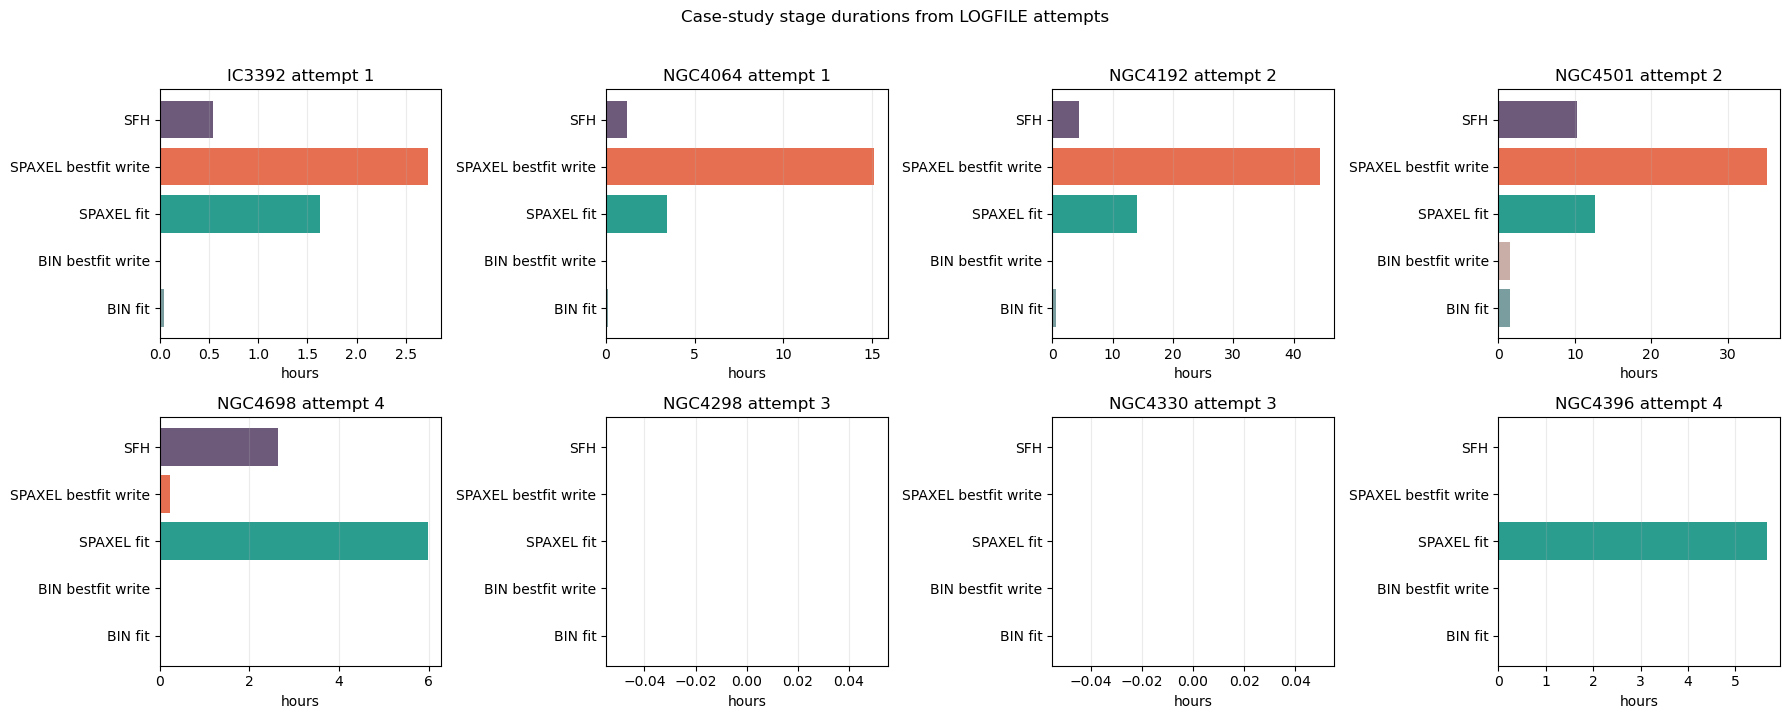

In [7]:
stage_cols = [
    ('bin_fit_hours', 'BIN fit'),
    ('bin_bestfit_write_hours', 'BIN bestfit write'),
    ('spaxel_fit_hours', 'SPAXEL fit'),
    ('spaxel_bestfit_write_hours', 'SPAXEL bestfit write'),
    ('sfh_hours', 'SFH'),
]
fig, axs = plt.subplots(2, 4, figsize=(18, 7), sharex=False)
axs = axs.ravel()
for ax, galaxy in zip(axs, CASE_GALAXIES):
    subset = log_attempts[log_attempts['galaxy'] == galaxy].copy()
    completed = subset[subset['has_gas_maps_start']]
    if not completed.empty:
        row = completed.sort_values('attempt_index').iloc[-1]
    else:
        row = subset.sort_values('attempt_index').iloc[-1]
    values = [0 if pd.isna(row[col]) else float(row[col]) for col, _ in stage_cols]
    labels = [label for _, label in stage_cols]
    colors = ['#7a9e9f', '#c9ada7', '#2a9d8f', '#e76f51', '#6d597a']
    ax.barh(labels, values, color=colors)
    ax.set_title(f"{galaxy} attempt {int(row['attempt_index'])}")
    ax.set_xlabel('hours')
    ax.grid(axis='x', alpha=0.25)
fig.suptitle('Case-study stage durations from LOGFILE attempts', y=1.02)
fig.tight_layout()
plt.show()


## Peak memory scaling

Cell 14 keeps the conservative reliable-gas-stage fit used for the queue-risk table. Cell 15 uses all available completed regular galaxies, one row per galaxy, but the plotted value is the highest observed regular gas-stage peak for that galaxy. The gray context jobs are omitted from the plot; likely memory-limit `FAILED` jobs are overlaid as red crosses using the `MaxRSS >= 0.98 * ReqMem` 220 GiB cap heuristic.


In [8]:
fit_display = memory_fits.copy()
fit_display['slope_gib_per_million'] = fit_display['slope_gib_per_unit'] * 1_000_000
fit_display = fit_display[['n', 'r', 'rmse_gib', 'slope_gib_per_million', 'intercept_gib']].round(3)
display(fit_display)

display(reliable_jobs[['jobid', 'galaxy', 'state', 'reqmem_gib', 'maxrss_gib', 'total_cube_spaxels', 'available_spaxels', 'n_bins', 'max_spaxel_bestfit_write_hours']].sort_values('maxrss_gib', ascending=False))

assert memory_fits.loc['total_cube_spaxels', 'r'] > memory_fits.loc['available_spaxels', 'r']
assert memory_fits.loc['total_cube_spaxels', 'r'] > 0.95
assert 'NGC4580' not in set(reliable_jobs['galaxy'])


,n,r,rmse_gib,slope_gib_per_million,intercept_gib
metric,,,,,
total_cube_spaxels,17,0.987,35.019,487.622,15.759
available_spaxels,17,0.905,93.668,1333.989,-72.950
n_bins,17,0.835,121.077,10609.429,102.525


,jobid,galaxy,state,reqmem_gib,maxrss_gib,total_cube_spaxels,available_spaxels,n_bins,max_spaxel_bestfit_write_hours
38,43065227,NGC4192,COMPLETED,980.0,884.0,1778868,523317,34395,44.436667
37,43065232,NGC4501,COMPLETED,980.0,732.0,1489380,663109,73938,35.093889
4,43186252,NGC4698,COMPLETED,980.0,471.0,722912,352169,23862,0.234167
12,43113885,NGC4293,COMPLETED,220.0,206.0,491036,261142,20458,3.288611
50,43057911,NGC4402,COMPLETED,220.0,197.0,366336,344422,7515,1.240833
49,43057912,NGC4405,COMPLETED,220.0,176.0,346086,178522,5665,8.906667
52,43057909,NGC4394,COMPLETED,220.0,172.0,403728,179299,13298,4.656111
53,43057908,NGC4388,COMPLETED,220.0,171.0,281010,266066,15475,6.630833
45,43057916,NGC4522,COMPLETED,220.0,169.0,388810,176065,2558,17.318889
23,43091803,NGC4294,COMPLETED,220.0,165.0,375921,178396,4531,16.751111


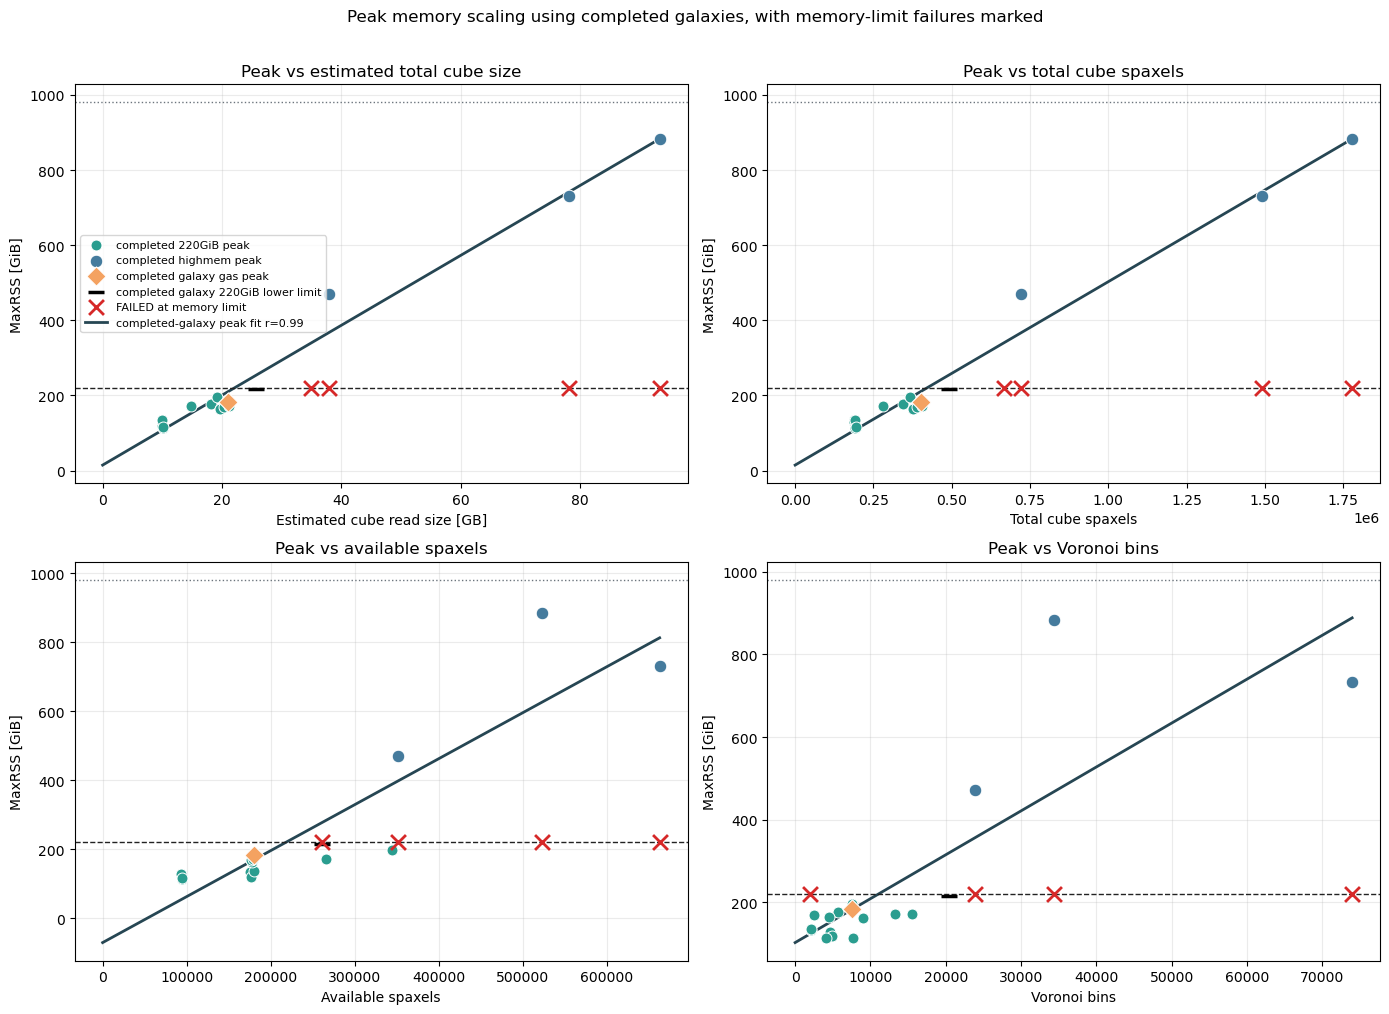

,n_completed_galaxies,r,rmse_gib,slope_gib_per_unit,intercept_gib
metric,,,,,
estimated_cube_read_size_gb,18,0.987,33.937,9.302,14.438
total_cube_spaxels,18,0.987,33.937,0.000,14.438
available_spaxels,18,0.906,90.701,0.001,-71.070
n_bins,18,0.837,117.150,0.011,102.917


,galaxy,jobid,state,representative_peak_source,reqmem_gib,maxrss_gib,total_cube_spaxels,available_spaxels,n_bins
38,NGC4192,43065227,COMPLETED,completed_job,980.0,884.0,1778868,523317,34395
37,NGC4501,43065232,COMPLETED,completed_job,980.0,732.0,1489380,663109,73938
4,NGC4698,43186252,COMPLETED,completed_job,980.0,471.0,722912,352169,23862
24,NGC4293,43091802,TIMEOUT,earlier_gas_attempt,220.0,216.0,491036,261142,20458
50,NGC4402,43057911,COMPLETED,completed_job,220.0,197.0,366336,344422,7515
14,NGC4580,43091812,TIMEOUT,earlier_gas_attempt,220.0,183.0,400493,179950,7560
49,NGC4405,43057912,COMPLETED,completed_job,220.0,176.0,346086,178522,5665
52,NGC4394,43057909,COMPLETED,completed_job,220.0,172.0,403728,179299,13298
53,NGC4388,43057908,COMPLETED,completed_job,220.0,171.0,281010,266066,15475
45,NGC4522,43057916,COMPLETED,completed_job,220.0,169.0,388810,176065,2558


,galaxy,jobid,state,reqmem_gib,maxrss_gib,mem_pct,total_cube_spaxels,available_spaxels,n_bins
5,NGC4698,43158820,FAILED,220.0,220.0,99.98,722912,352169,23862
6,NGC4396,43158806,FAILED,220.0,220.0,99.98,666665,261296,1947
46,NGC4501,43057915,FAILED,220.0,220.0,99.98,1489380,663109,73938
61,NGC4192,43057900,FAILED,220.0,220.0,99.98,1778868,523317,34395


Completed galaxies represented in cell 15 fits: 18
IC3392, NGC4064, NGC4189, NGC4192, NGC4293, NGC4294, NGC4351, NGC4388, NGC4394, NGC4402, NGC4405, NGC4501, NGC4522, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
NGC4580 plotted with gas-stage peak: job 43091812, state TIMEOUT, MaxRSS 183.0 GiB
Likely memory-limit FAILED jobs marked with red crosses: 4 (43057900, 43057915, 43158806, 43158820)
Estimated wavelength samples: 3281


In [9]:
# Estimated cube-read size from the configured 4800-8900 A window.
# The raw /scratch datacubes are not local here, so this is an in-memory size proxy:
# total spaxels x wavelength samples x (flux + variance) x float64 bytes.
MUSE_DLAMBDA_A = 1.25
LMIN_A = 4800
LMAX_A = 8900
N_WAVE_EST = int(round((LMAX_A - LMIN_A) / MUSE_DLAMBDA_A)) + 1
BYTES_PER_VALUE = 8
N_ARRAYS_READ = 2
BYTES_PER_DECIMAL_GB = 1e9

jobs = jobs.copy()
jobs['estimated_cube_read_size_gb'] = (
    jobs['total_cube_spaxels'] * N_WAVE_EST * N_ARRAYS_READ * BYTES_PER_VALUE / BYTES_PER_DECIMAL_GB
)

completed_galaxy_jobs = ng.representative_completed_galaxy_peaks(jobs).copy()
assert completed_galaxy_jobs['galaxy'].is_unique
completed_galaxy_jobs['estimated_cube_read_size_gb'] = (
    completed_galaxy_jobs['total_cube_spaxels'] * N_WAVE_EST * N_ARRAYS_READ * BYTES_PER_VALUE / BYTES_PER_DECIMAL_GB
)

likely_memory_limit_failures = jobs[
    (jobs['job_variant'] == 'regular')
    & (jobs['state'] == 'FAILED')
    & jobs['standard_mem_cap'].fillna(False)
    & jobs['total_cube_spaxels'].notna()
    & jobs['maxrss_gib'].notna()
].copy()

plot_specs = [
    ('estimated_cube_read_size_gb', 'Estimated cube read size [GB]', 'Peak vs estimated total cube size'),
    ('total_cube_spaxels', 'Total cube spaxels', 'Peak vs total cube spaxels'),
    ('available_spaxels', 'Available spaxels', 'Peak vs available spaxels'),
    ('n_bins', 'Voronoi bins', 'Peak vs Voronoi bins'),
]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs_flat = axs.ravel()
completed_fit_rows = []

for ax, (xcol, xlabel, title) in zip(axs_flat, plot_specs):
    memory_failure_points = likely_memory_limit_failures[likely_memory_limit_failures[xcol].notna()]

    peak_lower_limits = completed_galaxy_jobs[completed_galaxy_jobs['standard_mem_cap'].fillna(False)]
    peak_from_earlier_gas = completed_galaxy_jobs[
        (completed_galaxy_jobs['representative_peak_source'] == 'earlier_gas_attempt')
        & ~completed_galaxy_jobs['standard_mem_cap'].fillna(False)
    ]
    completed_peak_rows = completed_galaxy_jobs[
        (completed_galaxy_jobs['representative_peak_source'] == 'completed_job')
        & ~completed_galaxy_jobs['standard_mem_cap'].fillna(False)
    ]
    highmem_completed = completed_peak_rows[completed_peak_rows['reqmem_gib'] >= 900]
    standard_completed = completed_peak_rows[completed_peak_rows['reqmem_gib'] < 900]

    ax.scatter(
        standard_completed[xcol],
        standard_completed['maxrss_gib'],
        s=62,
        marker='o',
        color='#2a9d8f',
        edgecolor='white',
        linewidth=0.7,
        label='completed 220GiB peak',
        zorder=3,
    )
    ax.scatter(
        highmem_completed[xcol],
        highmem_completed['maxrss_gib'],
        s=82,
        marker='o',
        color='#457b9d',
        edgecolor='white',
        linewidth=0.7,
        label='completed highmem peak',
        zorder=3,
    )
    ax.scatter(
        peak_from_earlier_gas[xcol],
        peak_from_earlier_gas['maxrss_gib'],
        s=96,
        marker='D',
        facecolor='#f4a261',
        edgecolor='white',
        linewidth=0.8,
        label='completed galaxy gas peak',
        zorder=4,
    )
    ax.scatter(
        peak_lower_limits[xcol],
        peak_lower_limits['maxrss_gib'],
        s=120,
        marker='_',
        color='black',
        linewidth=2.5,
        label='completed galaxy 220GiB lower limit',
        zorder=5,
    )
    ax.scatter(
        memory_failure_points[xcol],
        memory_failure_points['maxrss_gib'],
        s=115,
        marker='x',
        color='#d62828',
        linewidth=2.0,
        label='FAILED at memory limit',
        zorder=6,
    )

    x = completed_galaxy_jobs[xcol].to_numpy(dtype=float)
    y = completed_galaxy_jobs['maxrss_gib'].to_numpy(dtype=float)
    design = np.vstack([x, np.ones_like(x)]).T
    slope, intercept = np.linalg.lstsq(design, y, rcond=None)[0]
    r_value = np.corrcoef(x, y)[0, 1]
    rmse = np.sqrt(np.mean((y - (slope * x + intercept)) ** 2))
    completed_fit_rows.append((xcol, len(x), r_value, rmse, slope, intercept))

    plotted_x = pd.concat([completed_galaxy_jobs[xcol], likely_memory_limit_failures[xcol]], ignore_index=True).dropna()
    xx = np.linspace(0, plotted_x.max(), 100)
    ax.plot(xx, slope * xx + intercept, color='#264653', lw=2, label=f'completed-galaxy peak fit r={r_value:.2f}')
    ax.axhline(220, color='#222222', lw=1, ls='--')
    ax.axhline(980, color='#6c757d', lw=1, ls=':')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('MaxRSS [GiB]')
    ax.set_title(title)
    ax.grid(alpha=0.25)

handles, labels = axs_flat[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
axs_flat[0].legend(unique.values(), unique.keys(), loc='best', fontsize=8)
fig.suptitle('Peak memory scaling using completed galaxies, with memory-limit failures marked', y=1.01)
fig.tight_layout()
plt.show()

completed_fit_table = pd.DataFrame(
    completed_fit_rows,
    columns=['metric', 'n_completed_galaxies', 'r', 'rmse_gib', 'slope_gib_per_unit', 'intercept_gib'],
).set_index('metric')
display(completed_fit_table.round(3))

galaxy_peak_table = completed_galaxy_jobs[
    ['galaxy', 'jobid', 'state', 'representative_peak_source', 'reqmem_gib', 'maxrss_gib', 'total_cube_spaxels', 'available_spaxels', 'n_bins']
].sort_values('maxrss_gib', ascending=False)
display(galaxy_peak_table)

memory_limit_failure_table = likely_memory_limit_failures[
    ['galaxy', 'jobid', 'state', 'reqmem_gib', 'maxrss_gib', 'mem_pct', 'total_cube_spaxels', 'available_spaxels', 'n_bins']
].sort_values('maxrss_gib', ascending=False)
display(memory_limit_failure_table)

ngc4580_peak = galaxy_peak_table[galaxy_peak_table['galaxy'] == 'NGC4580'].iloc[0]
assert int(ngc4580_peak['jobid']) == 43091812
assert float(ngc4580_peak['maxrss_gib']) == 183.0
assert set(likely_memory_limit_failures['state'].unique()) <= {'FAILED'}
assert (likely_memory_limit_failures['maxrss_gib'] >= 0.98 * likely_memory_limit_failures['reqmem_gib']).all()

print(f'Completed galaxies represented in cell 15 fits: {len(completed_galaxy_jobs)}')
print(', '.join(completed_galaxy_jobs.sort_values('galaxy')['galaxy'].tolist()))
print(f"NGC4580 plotted with gas-stage peak: job {int(ngc4580_peak['jobid'])}, state {ngc4580_peak['state']}, MaxRSS {float(ngc4580_peak['maxrss_gib']):.1f} GiB")
print(f"Likely memory-limit FAILED jobs marked with red crosses: {len(likely_memory_limit_failures)} ({', '.join(likely_memory_limit_failures.sort_values('jobid')['jobid'].astype(str))})")
print(f'Estimated wavelength samples: {N_WAVE_EST}')


## Queue-risk estimate

This is a guide, not a scheduling command. The prediction uses the `total_cube_spaxels` fit and reports one-RMSE uncertainty. The 220 GiB capped rows are treated as lower limits.


In [10]:
risk_cols = [
    'galaxy', 'total_cube_spaxels', 'available_spaxels', 'n_bins', 'observed_maxrss_gib',
    'standard_220gib_capped', 'completed_standard_220gib', 'completed_highmem',
    'predicted_maxrss_gib', 'prediction_rmse_gib', 'predicted_plus_rmse_gib', 'queue_risk'
]
risk_display = queue_risk[risk_cols].copy()
for col in ['observed_maxrss_gib', 'predicted_maxrss_gib', 'prediction_rmse_gib', 'predicted_plus_rmse_gib']:
    risk_display[col] = risk_display[col].round(1)
display(risk_display)

display(risk_display[risk_display['queue_risk'].isin(['highmem likely', 'highmem confirmed'])])


,galaxy,total_cube_spaxels,available_spaxels,n_bins,observed_maxrss_gib,standard_220gib_capped,completed_standard_220gib,completed_highmem,predicted_maxrss_gib,prediction_rmse_gib,predicted_plus_rmse_gib,queue_risk
3,NGC4192,1778868,523317,34395,884.0,True,False,True,883.2,35.0,918.2,highmem confirmed
18,NGC4501,1489380,663109,73938,732.0,True,False,True,742.0,35.0,777.0,highmem confirmed
6,NGC4298,1036790,483691,11808,220.0,True,False,False,521.3,35.0,556.3,highmem likely
20,NGC4567_8,1028289,508484,31715,220.0,True,False,False,517.2,35.0,552.2,highmem likely
25,NGC4698,722912,352169,23862,471.0,True,False,True,368.3,35.0,403.3,highmem confirmed
8,NGC4330,669560,260124,2851,220.0,True,False,False,342.3,35.0,377.3,highmem likely
13,NGC4396,666665,261296,1947,220.0,True,False,False,340.8,35.0,375.9,highmem likely
17,NGC4457,525625,336611,19306,220.0,True,False,False,272.1,35.0,307.1,highmem likely
4,NGC4293,491036,261142,20458,216.0,True,True,False,255.2,35.0,290.2,borderline or highmem
7,NGC4302,457240,421756,10734,181.0,False,False,False,238.7,35.0,273.7,borderline or highmem


,galaxy,total_cube_spaxels,available_spaxels,n_bins,observed_maxrss_gib,standard_220gib_capped,completed_standard_220gib,completed_highmem,predicted_maxrss_gib,prediction_rmse_gib,predicted_plus_rmse_gib,queue_risk
3,NGC4192,1778868,523317,34395,884.0,True,False,True,883.2,35.0,918.2,highmem confirmed
18,NGC4501,1489380,663109,73938,732.0,True,False,True,742.0,35.0,777.0,highmem confirmed
6,NGC4298,1036790,483691,11808,220.0,True,False,False,521.3,35.0,556.3,highmem likely
20,NGC4567_8,1028289,508484,31715,220.0,True,False,False,517.2,35.0,552.2,highmem likely
25,NGC4698,722912,352169,23862,471.0,True,False,True,368.3,35.0,403.3,highmem confirmed
8,NGC4330,669560,260124,2851,220.0,True,False,False,342.3,35.0,377.3,highmem likely
13,NGC4396,666665,261296,1947,220.0,True,False,False,340.8,35.0,375.9,highmem likely
17,NGC4457,525625,336611,19306,220.0,True,False,False,272.1,35.0,307.1,highmem likely


## Detailed summary

The main correction is that the relevant memory column is `MaxRSS`, not `AveRSS`. In the recent Setonix records, `AveRSS` is typically about half of `MaxRSS`, so it substantially underestimates the memory ceiling pressure. The IC3392 control runs also show that the SPAXEL-only run (`125 GiB`) is slightly higher than the regular BOTH-level run (`113 GiB`), while the BIN-only test is much lower (`63.1 GiB`). That argues against the simple interpretation that memory is dominated by holding BIN and SPAXEL products together.

For the scaling plots in cell 15, the displayed fits use all available completed regular galaxies, one representative point per galaxy. The representative point is the highest observed regular gas-stage peak for that galaxy, not necessarily the final completed Slurm job. The gray context jobs are now omitted. Likely memory-limit `FAILED` jobs are marked separately as red crosses when `MaxRSS >= 0.98 * ReqMem`; this identifies capped failures without mixing them into the timeout layer. NGC4580 is still represented by the earlier `183 GiB` gas-stage timeout (`43091812`) rather than the final SFH-only completion at `50.1 GiB`.

Across the completed-galaxy gas-peak set, peak memory still tracks the full cube footprint most directly. The first panel converts that footprint into an estimated cube-read size in GB. That GB value is not a measured raw FITS file size because the `/scratch/...DATACUBE...fits` inputs are not local in this checkout; it is a consistent proxy using the configured 4800-8900 A wavelength window, MUSE 1.25 A sampling, and two float64 arrays for flux and variance. The total-footprint panel should therefore be read together with the GB proxy panel.

There is also an earlier, smaller memory-pressure phase before emission-line fitting. The nGIST read-in stage reads the MUSE flux cube and variance cube, shifts to rest frame, trims to 4800-8900 A, and computes per-spaxel S/N while keeping `cube["spec"]` and `cube["error"]` as full `(wavelength, spaxel)` arrays. For the largest local logs this is already large: NGC4192 reads `1,778,868` spectra and NGC4501 reads `1,489,380` spectra. With the current wavelength window, one trimmed float64 cube-like matrix is about `46.7 GB` for NGC4192 and `39.1 GB` for NGC4501, before counting variance and temporary arrays.

The early LOGFILE timing is consistent with a real setup/binning peak rather than only a gas-output peak. NGC4192 spends about `83 min` defining Voronoi bins (`34,395` bins), and NGC4501 spends about `109 min` (`73,938` bins). The source path then applies spatial bins to the linear spectra, log-rebins all spectra and all error spectra, writes `_all_spectra.hdf5` when `GAS.LEVEL` is `SPAXEL` or `BOTH`, and finally applies spatial bins to the log data. That can temporarily hold the original spectra/error, log-rebinned spectra/error, and binned products. This should still be lower than the later SPAXEL gas bestfit-write peak because it does not yet also hold per-spaxel pPXF outputs, `bestfit`, `gas_bestfit`, `cleaned`, and FITS-table copies. Resumed jobs can still show an early read peak because the LOGFILEs show the cube being re-read before downstream modules are skipped or resumed.

The LOGFILE timing supports the gas-stage interpretation. BIN and SPAXEL fitting run sequentially: BIN mode writes `*_gas_bin.fits` and `*_gas_bestfit_bin.fits` before SPAXEL mode starts. For the large completed highmem cases, the long delay is after SPAXEL PPXF and after `*_gas_spaxel.fits`, while writing `*_gas_bestfit_spaxel.fits`: about `44.4 h` for NGC4192 and `35.1 h` for NGC4501. Source inspection explains why this stage can be much worse than read/binning: SPAXEL gas fitting reads the full `_all_spectra.hdf5`, stores spectra and error arrays, collects per-spaxel pPXF results, allocates full `bestfit` and `gas_bestfit` matrices, constructs `cleaned = spectra.T - gas_bestfit`, and creates FITS binary-table HDUs for cleaned spectra, bestfit, and gas-bestfit products. Several cube-sized arrays plus Astropy table copies can plausibly turn the `46.7 GB`/`39.1 GB` single-matrix footprints into the observed `884 GiB` and `732 GiB` job peaks.

For queue decisions, the 220 GiB jobs that hit `MaxRSS ~= ReqMem` should be treated as censored lower limits. NGC4192 and NGC4501 are confirmed highmem cases; NGC4698 also completed on highmem after repeated capped 220 GiB attempts. Based on the current scaling and capped failures, NGC4298, NGC4567_8, NGC4330, and NGC4396 are strong highmem candidates, while NGC4293, NGC4302, NGC4383, NGC4419, and NGC4457 remain borderline or stage-dependent. The practical implication is that the PHANGS-scale cubes are probably manageable on highmem in BIN mode, but full SPAXEL/BOTH products can be limited first by read/prepare memory pressure and then much more severely by the SPAXEL bestfit write stage. Those jobs should be monitored through both phases, and splitting or disabling full SPAXEL bestfit-style outputs would be the most direct mitigation if highmem still approaches the ceiling.


In [11]:
print('Notebook checks complete.')
print(f"total-spaxel memory-fit r = {memory_fits.loc['total_cube_spaxels', 'r']:.3f}")
print(f"available-spaxel memory-fit r = {memory_fits.loc['available_spaxels', 'r']:.3f}")
print(f"NGC4192 spaxel-bestfit write hours = {float(ngc4192['spaxel_bestfit_write_hours']):.2f}")
print(f"NGC4501 spaxel-bestfit write hours = {float(ngc4501['spaxel_bestfit_write_hours']):.2f}")


Notebook checks complete.
total-spaxel memory-fit r = 0.987
available-spaxel memory-fit r = 0.905
NGC4192 spaxel-bestfit write hours = 44.44
NGC4501 spaxel-bestfit write hours = 35.09
